# Hotels in India 2023 Analytics

This is an analytics project which does EDA on a hotel accomodation dataset of all star category in India. Please note some hotels may not be available. Only hotels registered under the ministry of tourism are available.  

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing Dataset

In [2]:
df = pd.read_csv("/kaggle/input/star-category-hotel-in-india-dataset2023/csv_data.csv")

In [3]:
df.head()

,S.No.,State,City,Category,Alcohol,Hotel Name,Address,Start Date,Expiry Date,Total Rooms
0,1,Delhi,New Delhi,1 Star,NaN,Hotel LA (A unit of L A Hotels And Retreats Pv...,"plot no A-1, Community Centre, Road No 43, Man...",20/01/2020,19/01/2025,35
1,2,Gujarat,Adalaj,1 Star,NaN,"Amba Suites, Unit of Amba Township Private Lim...","Amba Business Park, Shivam â€“ II, Sub-Plot No...",15/07/2022,14/07/2027,64
2,3,Gujarat,Ahmedabad,1 Star,NaN,Hotel Pragati The Grand (A Unit of Pragati The...,"SP-2,FP 2342,PAIKI, NR ZYDUS CADILA HOSPITAL,H...",22/09/2021,21/09/2026,45
3,4,Gujarat,Ahmedabad,1 Star,NaN,Hotel Rezaas,"375-1, Sheetal Baug, Nr. Girish Cold Drink, Of...",31/10/2018,30/10/2023,38
4,5,Gujarat,Anand,1 Star,NaN,HOTEL ARIZONA INN,"OPP. S R PARK, ANAND- SOJITRA ROAD, ANAND- 388001",01/09/2020,31/08/2025,28


## Data Preprocessing

In [4]:
df.describe()

,S.No.,Total Rooms
count,1212.000000,1212.000000
mean,606.500000,75.646865
std,350.018571,93.098648
min,1.000000,10.000000
25%,303.750000,15.000000
50%,606.500000,41.000000
75%,909.250000,102.000000
max,1212.000000,1024.000000


In [5]:
df.columns

Index(['S.No.', 'State', 'City', 'Category', 'Alcohol', 'Hotel Name',
       'Address', 'Start Date', 'Expiry Date', 'Total Rooms'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   S.No.        1212 non-null   int64 
 1   State        1212 non-null   object
 2   City         1212 non-null   object
 3   Category     1212 non-null   object
 4   Alcohol      676 non-null    object
 5   Hotel Name   1212 non-null   object
 6   Address      1212 non-null   object
 7   Start Date   1212 non-null   object
 8   Expiry Date  1212 non-null   object
 9   Total Rooms  1212 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 94.8+ KB


Removing S.No. column

In [7]:
df.drop('S.No.',inplace=True,axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   State        1212 non-null   object
 1   City         1212 non-null   object
 2   Category     1212 non-null   object
 3   Alcohol      676 non-null    object
 4   Hotel Name   1212 non-null   object
 5   Address      1212 non-null   object
 6   Start Date   1212 non-null   object
 7   Expiry Date  1212 non-null   object
 8   Total Rooms  1212 non-null   int64 
dtypes: int64(1), object(8)
memory usage: 85.3+ KB


#### Checking for Null values and treating them

In [9]:
df.isnull().sum()

State            0
City             0
Category         0
Alcohol        536
Hotel Name       0
Address          0
Start Date       0
Expiry Date      0
Total Rooms      0
dtype: int64

Above info shows that Alcohol column has 536 NaN values.

In [10]:
df["Alcohol"].unique()

array([nan, 'With Alcohol', 'Without Alcohol'], dtype=object)

Filling NaN values with "Not Mentioned"

In [11]:
df["Alcohol"].fillna("Not Mentioned",inplace=True)

In [12]:
df["Alcohol"].unique()

array(['Not Mentioned', 'With Alcohol', 'Without Alcohol'], dtype=object)

Hence all null values have been treated

In [13]:
df["State"].unique()

array(['Delhi', 'Gujarat', 'Madhya Pradesh', 'Maharashtra',
       'Andaman And Nicobar', 'Assam', 'Himachal Pradesh', 'Kerala',
       'Odisha', 'Rajasthan', 'Andhra Pradesh', 'Arunachal Pradesh',
       'Bihar', 'Chhattisgarh', 'Goa', 'Haryana', 'Karnataka', 'Manipur',
       'Meghalaya', 'Punjab', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'DNH & DD', 'Jharkhand', 'Tripura',
       'Chandigarh', 'Ladakh'], dtype=object)

Above column(State) contains both Indian States and its Union Territories

In [14]:
df["Category"].unique()

array(['1 Star', '2 Star', '3 Star', '4 Star', '5 Star'], dtype=object)

#### Checking Category column

Category has to be changed from object to int. First 'star' has to be removed

In [15]:
df["Category"] = df["Category"].str.split(" ").str[0]

In [16]:
df["Category"].head()

0    1
1    1
2    1
3    1
4    1
Name: Category, dtype: object

Converting data type: object to int

In [17]:
df = df.astype({'Category':'int'})

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   State        1212 non-null   object
 1   City         1212 non-null   object
 2   Category     1212 non-null   int64 
 3   Alcohol      1212 non-null   object
 4   Hotel Name   1212 non-null   object
 5   Address      1212 non-null   object
 6   Start Date   1212 non-null   object
 7   Expiry Date  1212 non-null   object
 8   Total Rooms  1212 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 85.3+ KB


Changing Column name: Category to StarRating

In [19]:
df.rename(columns={'Category':'StarRating'},inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   State        1212 non-null   object
 1   City         1212 non-null   object
 2   StarRating   1212 non-null   int64 
 3   Alcohol      1212 non-null   object
 4   Hotel Name   1212 non-null   object
 5   Address      1212 non-null   object
 6   Start Date   1212 non-null   object
 7   Expiry Date  1212 non-null   object
 8   Total Rooms  1212 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 85.3+ KB


#### Checking City column

In [21]:
df["City"]

0       New Delhi
1          Adalaj
2       Ahmedabad
3       Ahmedabad
4           Anand
          ...    
1207       MUMBAI
1208     Dehradun
1209     Durgapur
1210      Kolkata
1211     Siliguri
Name: City, Length: 1212, dtype: object

Some cities have '*' at its end. We will remove them

In [22]:
df['City'] = df['City'].str.split('*').str[0]
df['City'].unique()

array(['New Delhi', 'Adalaj', 'Ahmedabad', 'Anand', 'Bhavnagar',
       'Gandhinagar', 'Morvi', 'Rajkot', 'Surat', 'Vadodara', 'Veraval',
       'Dhar', 'Lonavala', 'Port Blair', 'Dibrugarh', 'Guwahati',
       'Dwarka', 'Gandhidham', 'Jamnagar', 'Kevadiya', 'Morabi',
       'Navsari', 'Porbandar', 'Saurashtra', 'Manali',
       'Thiruvananthapuram', 'Kollhapur', 'SANTACURZ', 'Sambalpur',
       'Alwar', 'East Godavari', 'Kakinada', 'Kurnool', 'Nellore',
       'Rajahmundry', 'Rajam', 'Tirupati', 'Vijayawada', 'Visakhapatnam',
       'Itanagar', 'West Kameng', 'Jorhat', 'Kokrajhar', 'Mangaldoi',
       'Nagaon', 'Bodhgaya', 'Bilaspur', 'Durg-Bhilai Nagar', 'Korba',
       'Raigarh', 'Raipur', 'Rajnandgaon', 'Margao', 'vasco da gama',
       'Bharuch', 'Bhuj', 'Dang', 'Kutch', 'Mahesana', 'Morbi', 'Sanand',
       'Talaja', 'Vapi', 'Viramgam', 'Ambala', 'Gurgaon', 'Rewari',
       'Solan', 'Bangalore', 'Adoor', 'Alappuzha', 'Angamaly', 'Attingal',
       'Calicut', 'Chalakudy', 'Changan

## Data Visualization

Data will be visualized using seaborn library. Various charts like bar chart will be used by taking different parameters like state, city, star rating, total rooms, etc.

#### Hotels in different States

In [23]:
s_names = df.State.value_counts().index
s_hotels = df.State.value_counts().values

In [24]:
hotels = df.groupby('State').size().reset_index().rename(columns={0:'Hotels','State':'States'})
hotels

,States,Hotels
0,Andaman And Nicobar,4
1,Andhra Pradesh,32
2,Arunachal Pradesh,3
3,Assam,16
4,Bihar,3
5,Chandigarh,2
6,Chhattisgarh,27
7,DNH & DD,2
8,Delhi,42
9,Goa,38


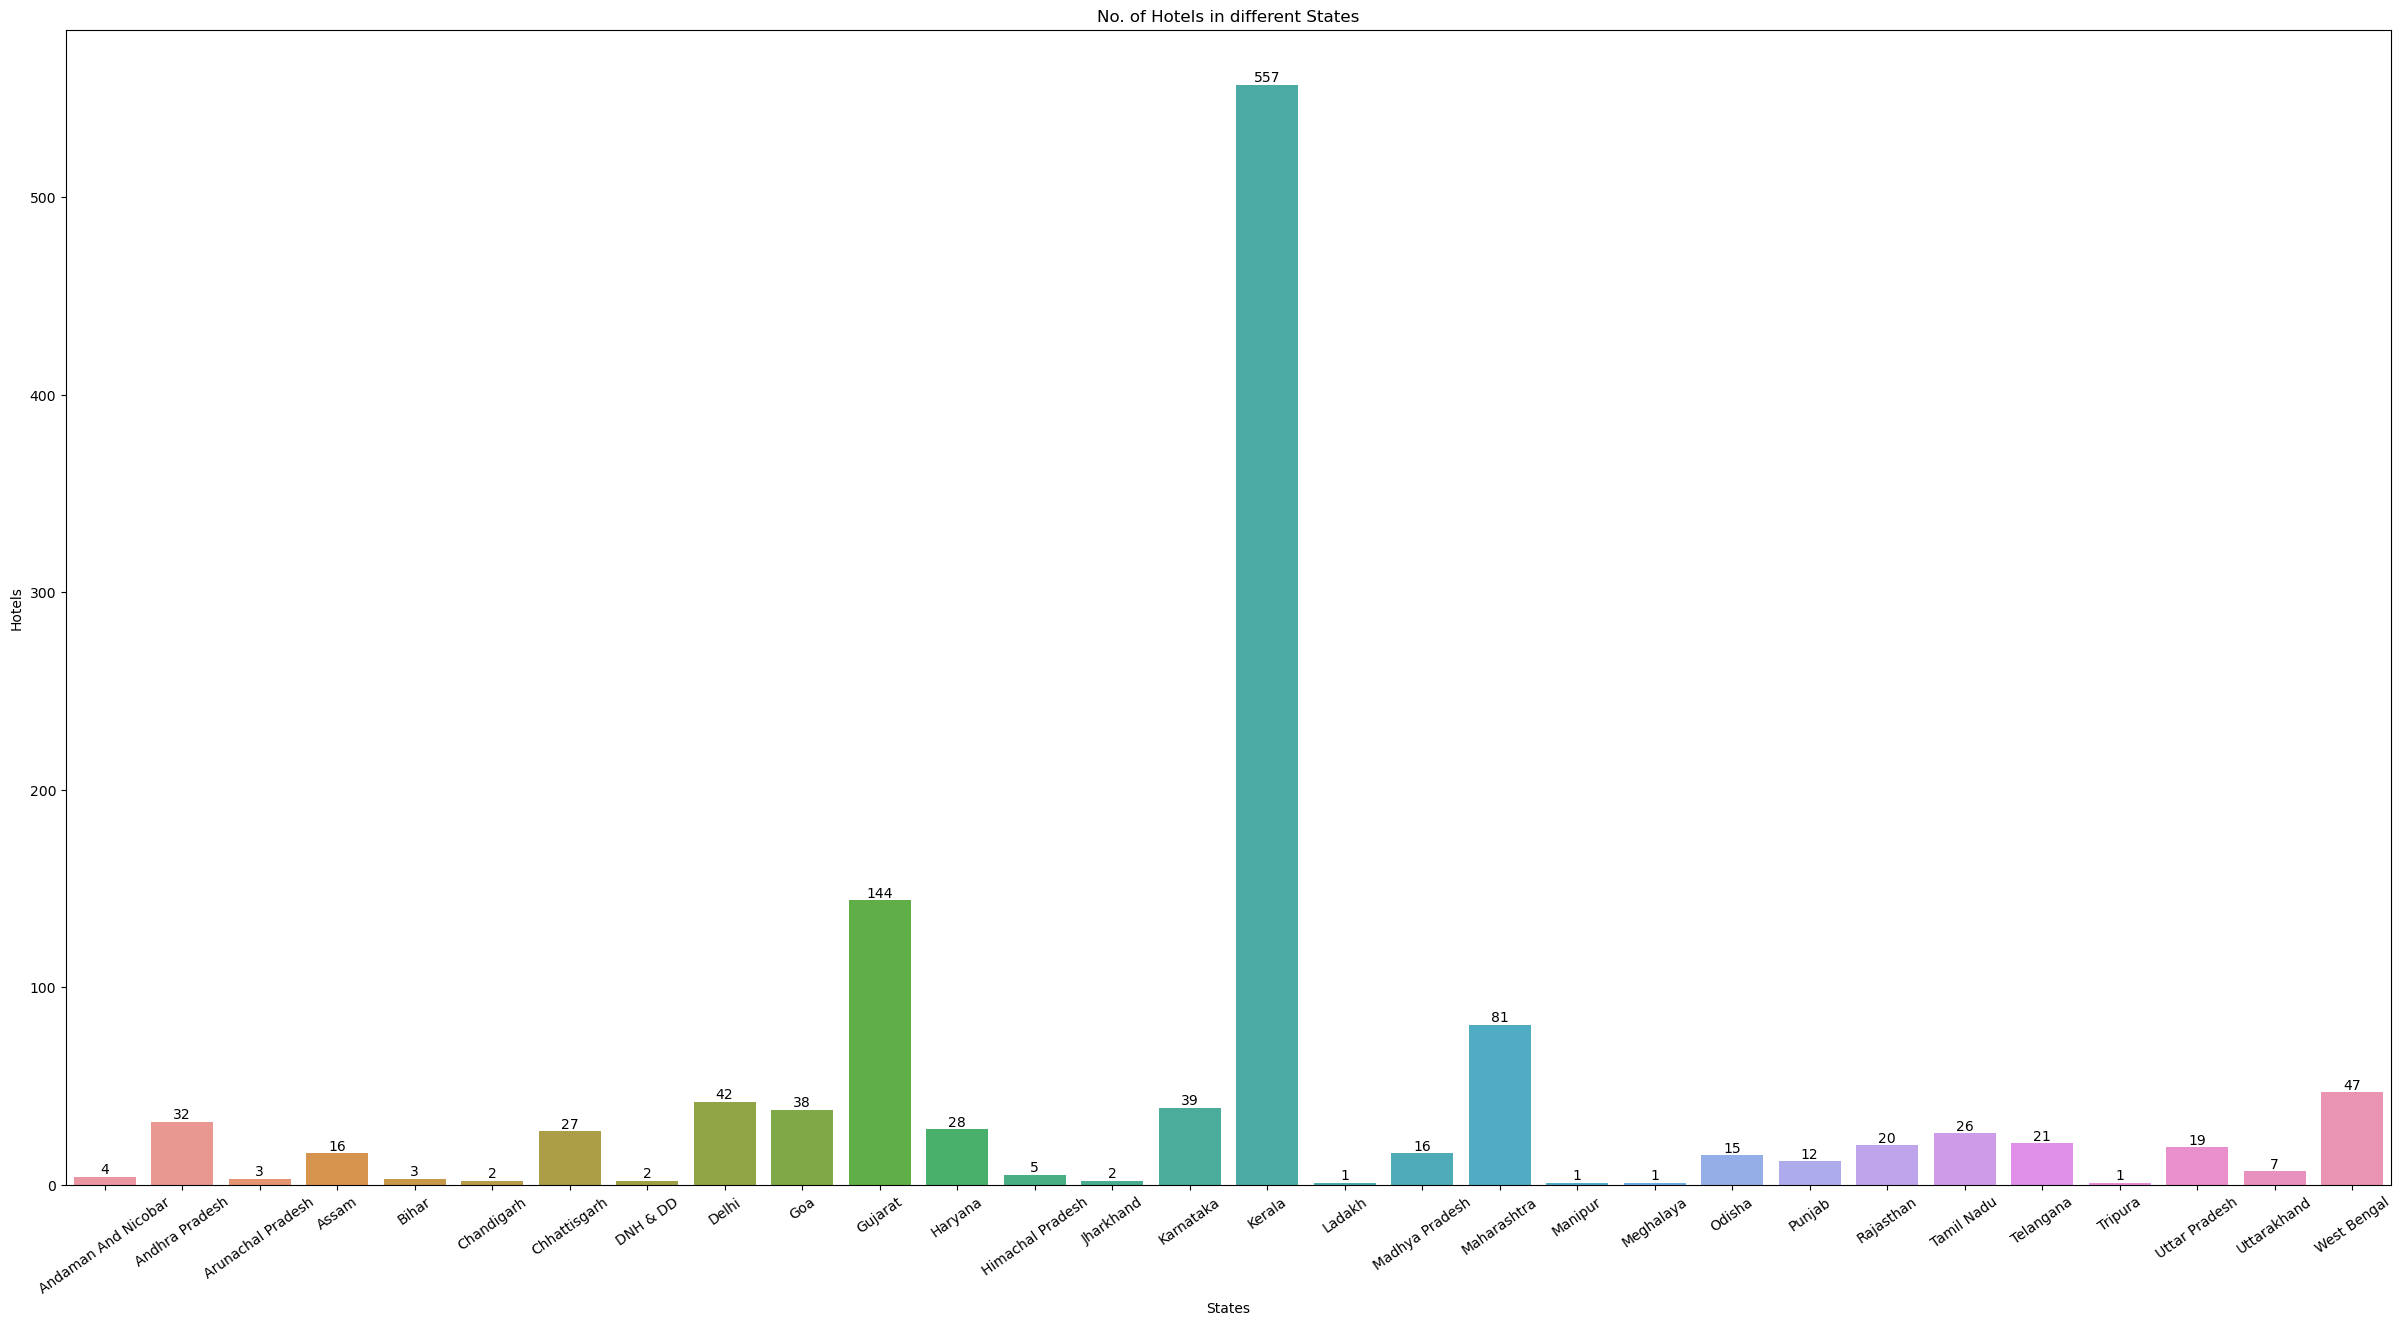

In [25]:
matplotlib.rcParams['figure.figsize'] = (30,15)
p = sns.barplot(x='States',y='Hotels',data = hotels)
p.bar_label(p.containers[0])
plt.title("No. of Hotels in different States")
p.set_xticklabels(labels=hotels["States"], rotation=35)
sns.set(font_scale=1.25)
plt.show()

The above chart shows Kerala has the highest number of hotels(557) registered under the Ministry Of Tourism, India.

#### Hotels based on star rating

In [26]:
ratings = df.StarRating.value_counts().index
ratings_count = df.StarRating.value_counts().values

In [27]:
ratings

Int64Index([3, 4, 5, 2, 1], dtype='int64')

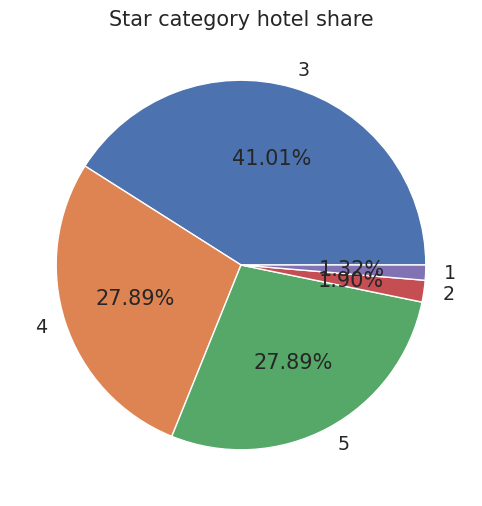

In [28]:
matplotlib.rcParams['figure.figsize'] = (12,6)
plt.pie(ratings_count,labels=ratings,autopct="%1.2f%%")
plt.title("Star category hotel share")
plt.show()

In [29]:
rating = df.groupby('StarRating').size().reset_index()
rating

,StarRating,0
0,1,16
1,2,23
2,3,497
3,4,338
4,5,338


Therefore 3 star hotels dominate the tourism industry!

#### Hotels based on city

Visualizing top 10 cities with highest no. of hotels

In [30]:
h_in_city = df.groupby("City").size().reset_index().rename(columns={0:'Hotels'})
h_in_city = h_in_city.sort_values(by='Hotels',ascending=False) #sorting based on no. of hotels

In [31]:
h_in_city[0:9]

,City,Hotels
62,Ernakulam,100
219,Thiruvananthapuram,58
222,Thrissur,57
109,Kollam,43
141,Mumbai,39
4,Ahmedabad,36
22,Bangalore,34
108,Kolkata,33
112,Kottayam,30


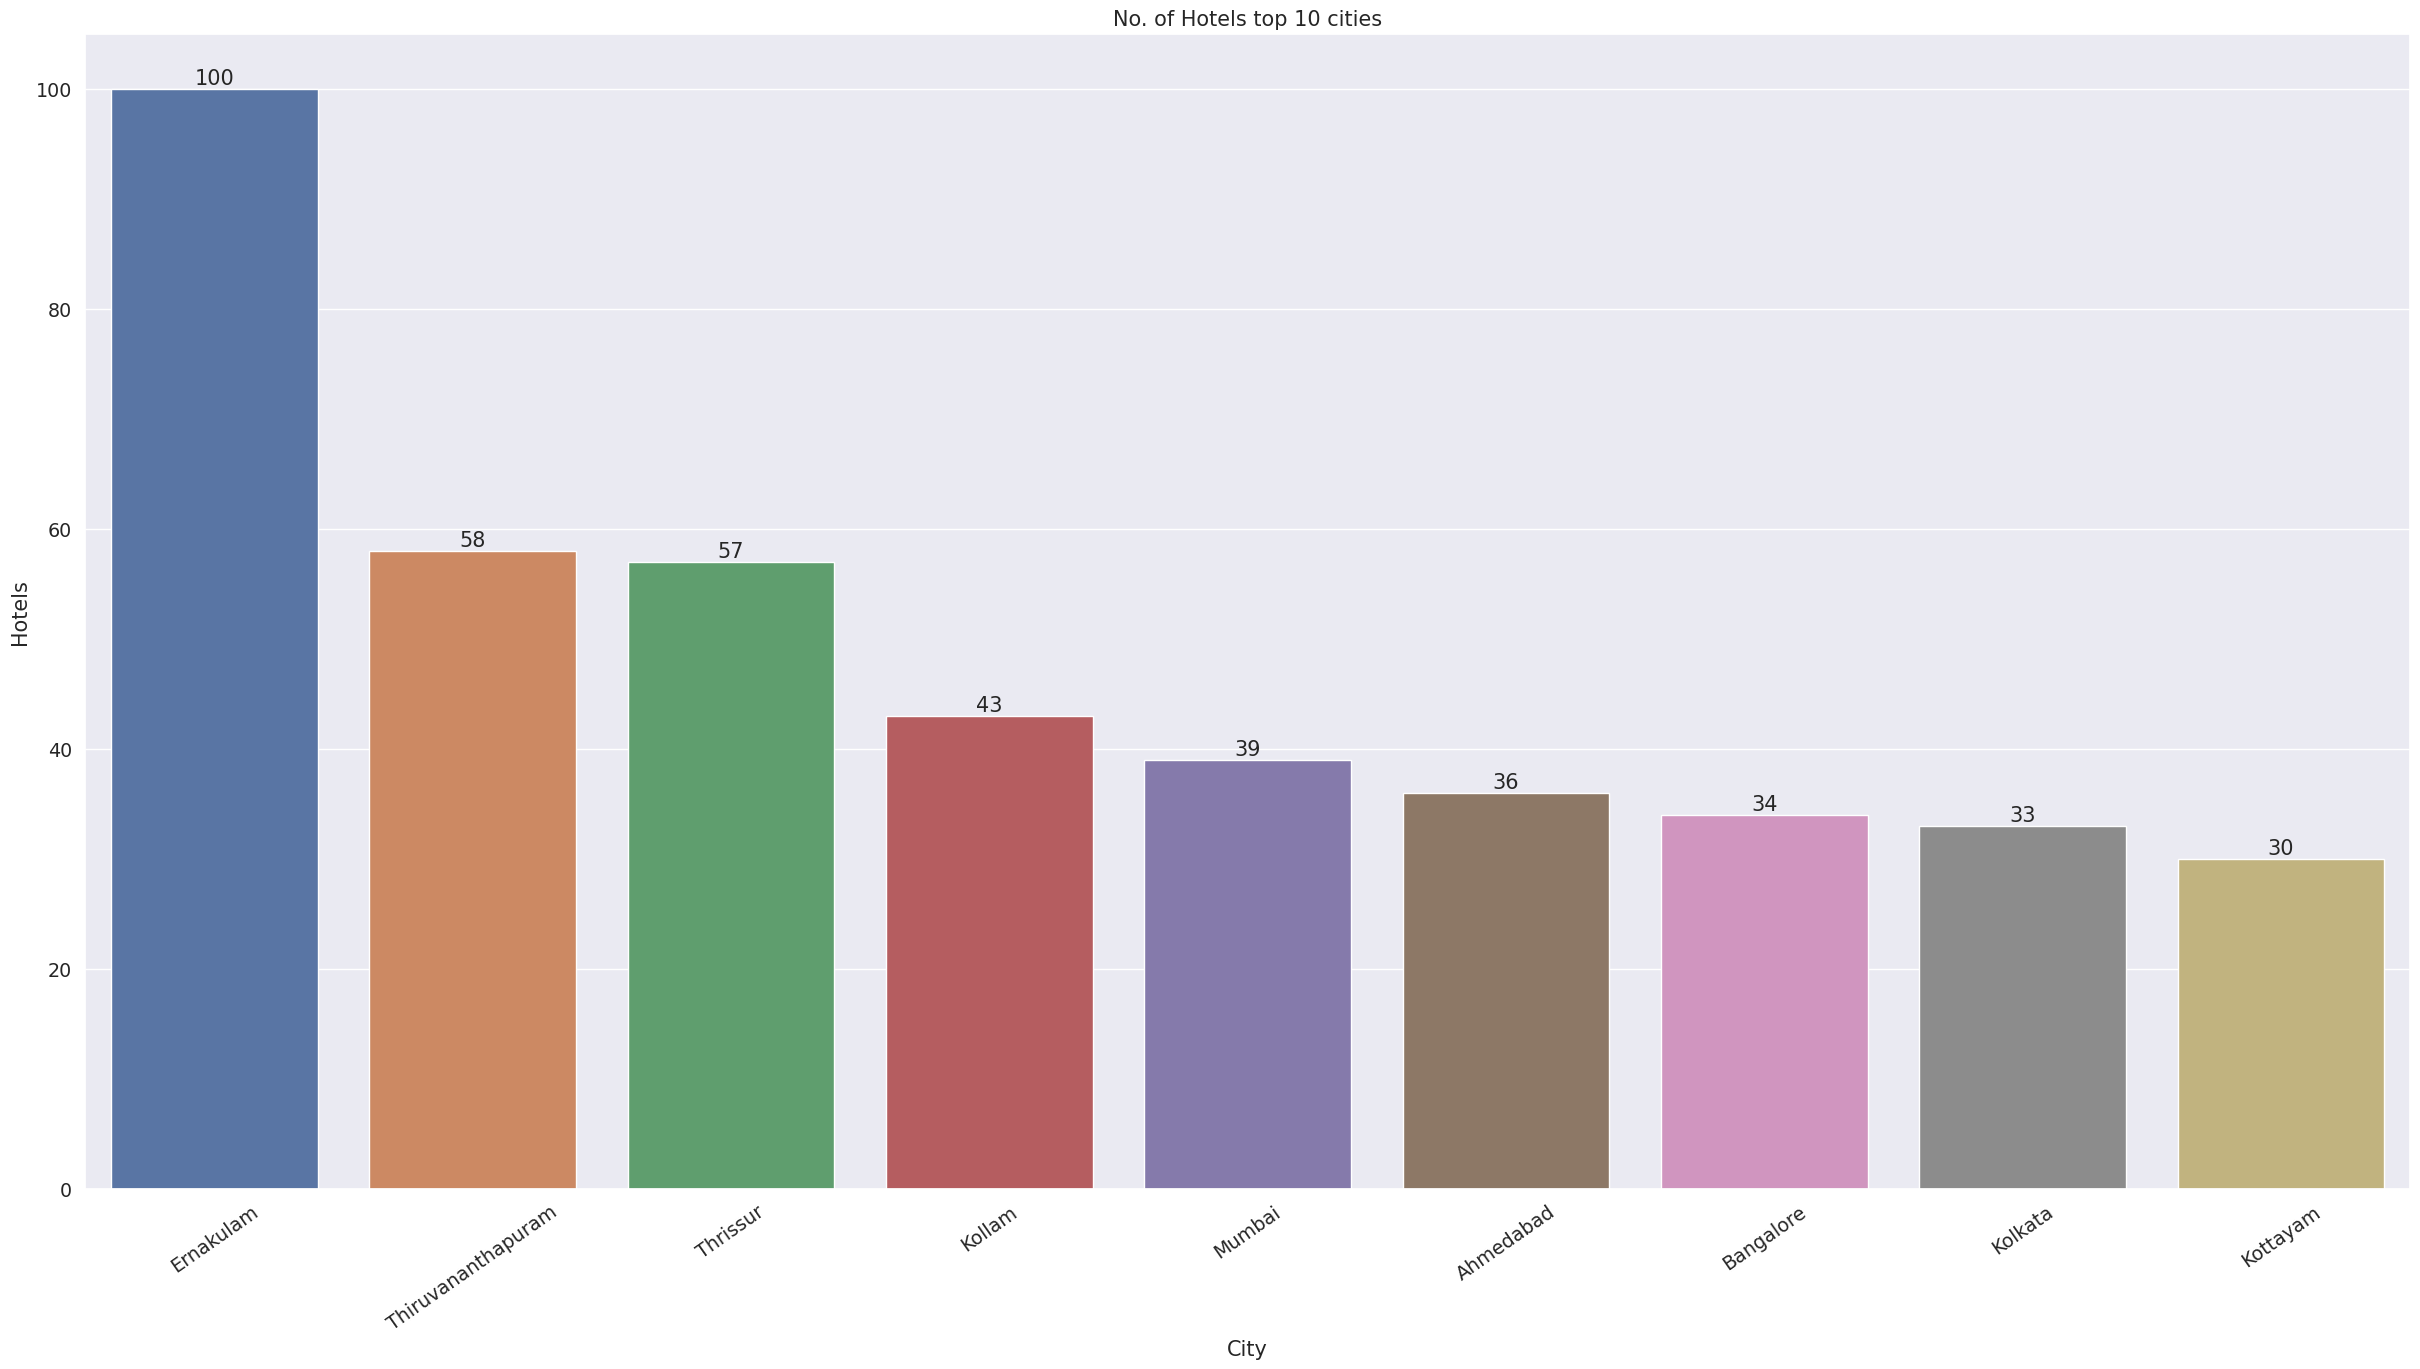

In [32]:
matplotlib.rcParams['figure.figsize'] = (30,15)
p = sns.barplot(x='City',y='Hotels',data = h_in_city[0:9])
p.bar_label(p.containers[0])
plt.title("No. of Hotels top 10 cities")
p.set_xticklabels(labels=h_in_city["City"][0:9], rotation=35)
sns.set(font_scale=1.25)
plt.show()

Ernakulam has the most no. of hotels

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   State        1212 non-null   object
 1   City         1212 non-null   object
 2   StarRating   1212 non-null   int64 
 3   Alcohol      1212 non-null   object
 4   Hotel Name   1212 non-null   object
 5   Address      1212 non-null   object
 6   Start Date   1212 non-null   object
 7   Expiry Date  1212 non-null   object
 8   Total Rooms  1212 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 85.3+ KB


#### Total Rooms in each state

In [34]:
s_rooms = df.groupby('State')['Total Rooms'].sum().reset_index()
s_rooms.head()

,State,Total Rooms
0,Andaman And Nicobar,208
1,Andhra Pradesh,3079
2,Arunachal Pradesh,127
3,Assam,852
4,Bihar,264


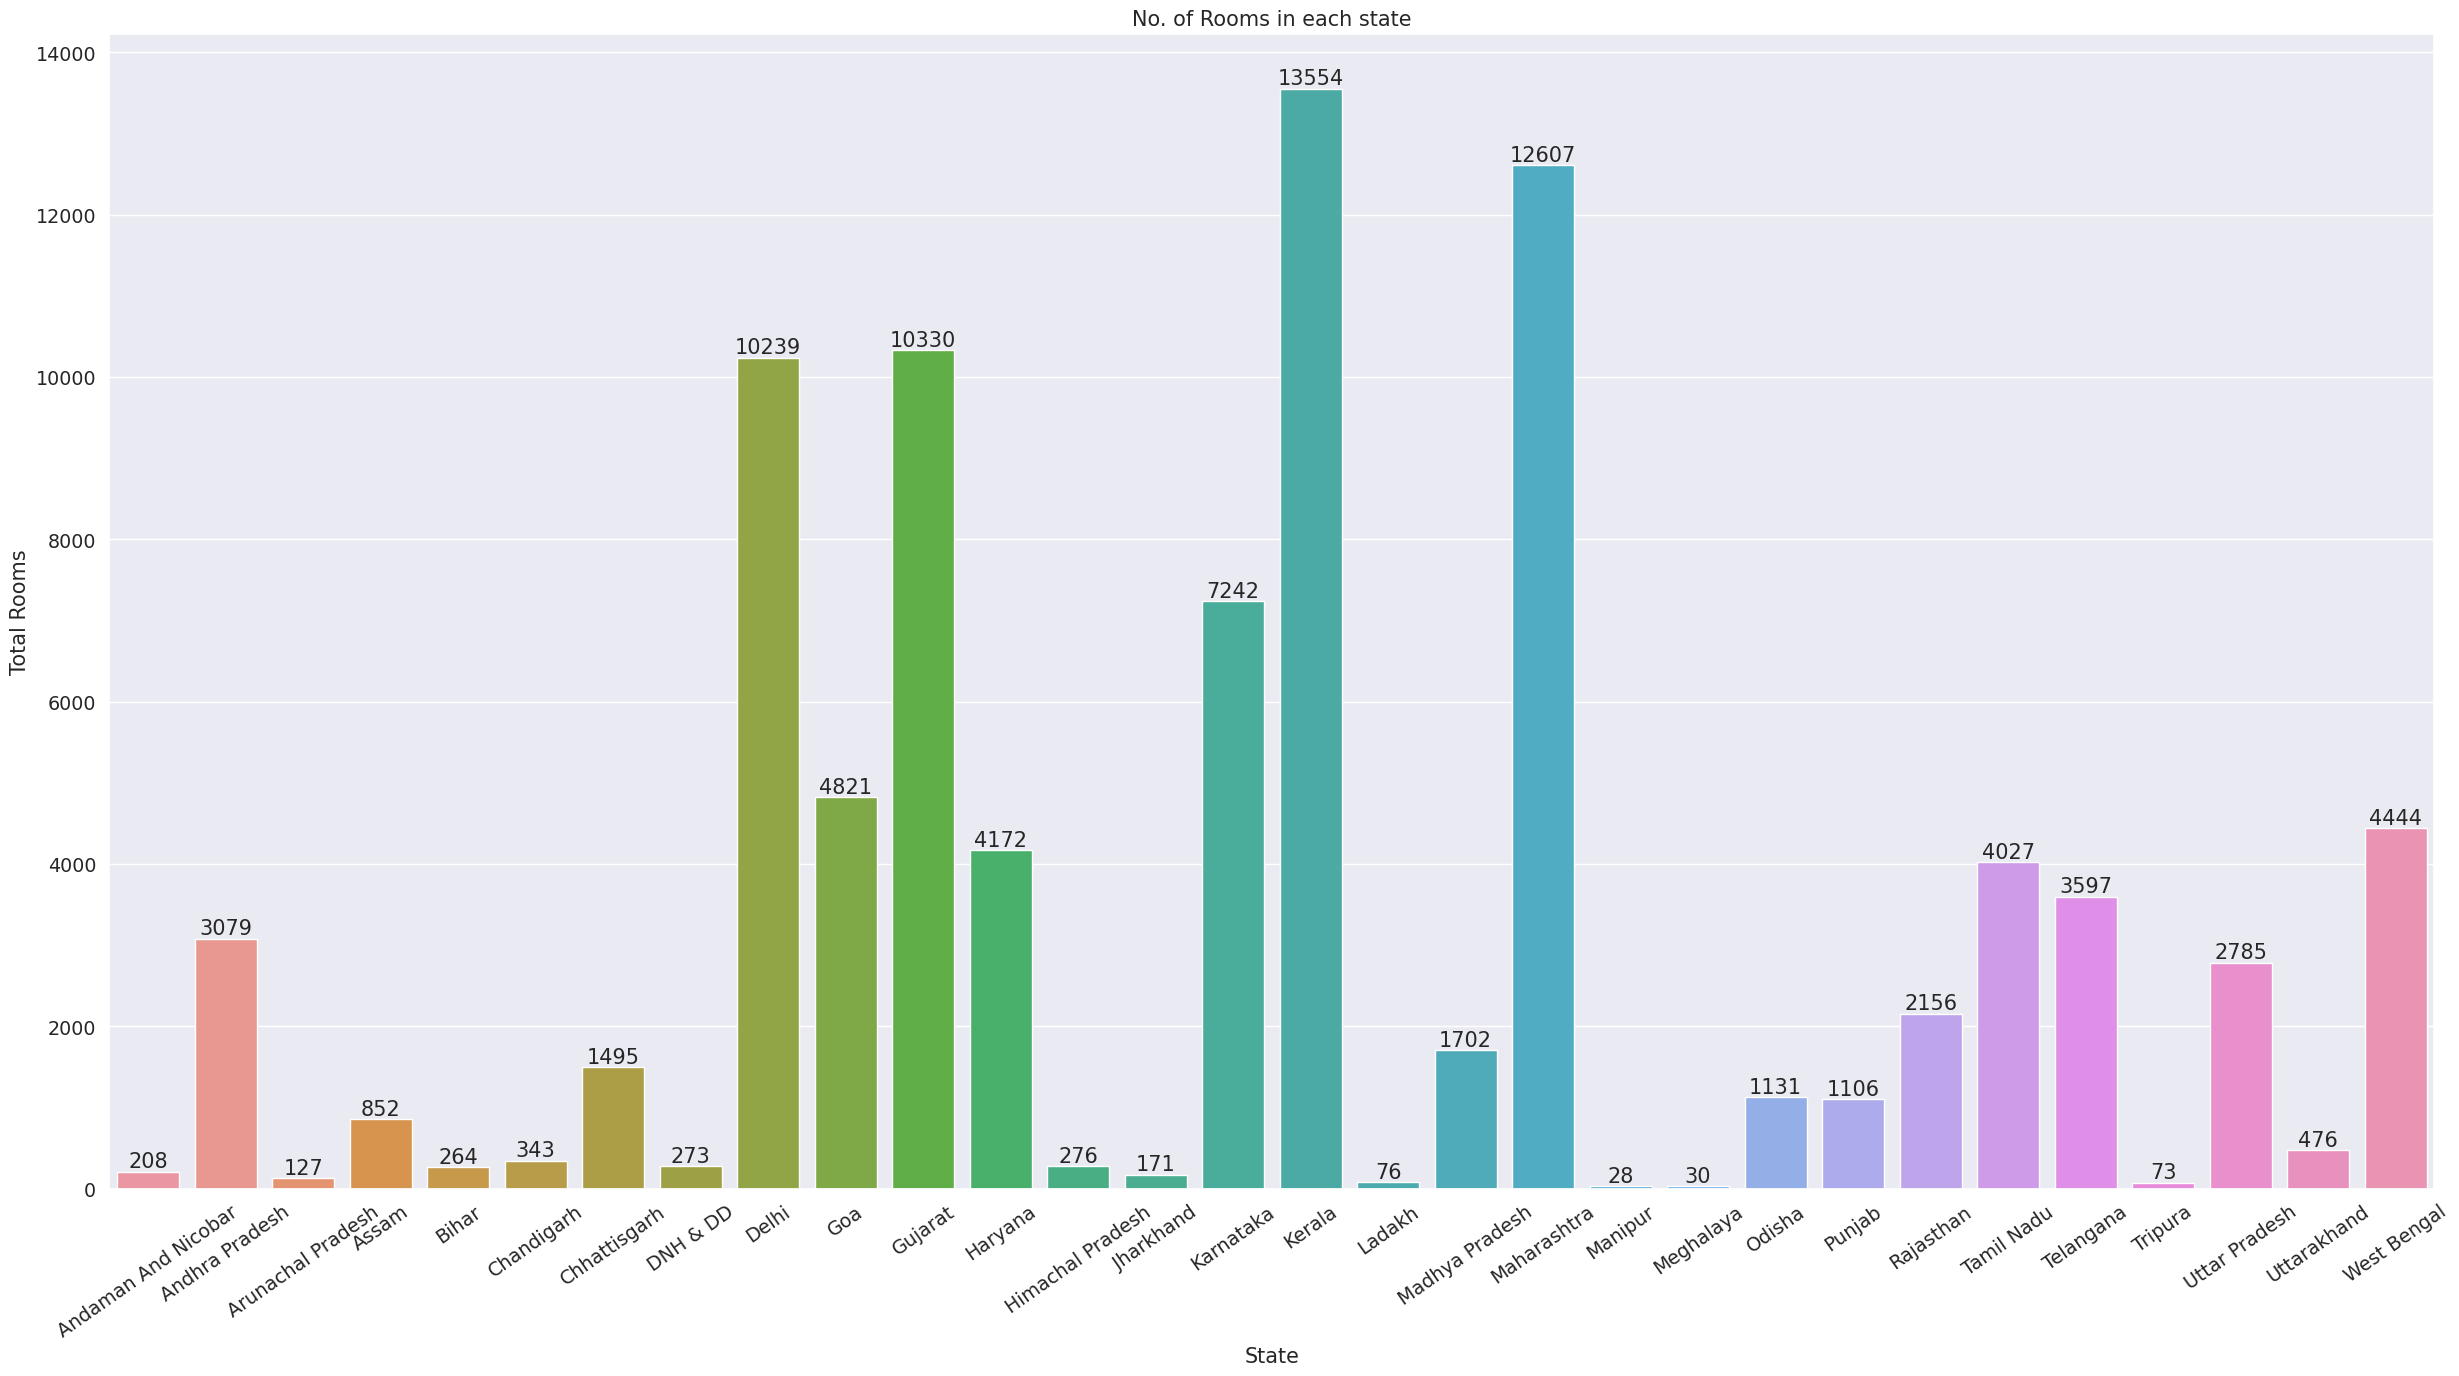

In [35]:
matplotlib.rcParams['figure.figsize'] = (30,15)
p = sns.barplot(x='State',y='Total Rooms',data = s_rooms)
p.bar_label(p.containers[0])
plt.title("No. of Rooms in each state")
p.set_xticklabels(labels=s_rooms["State"], rotation=35)
sns.set(font_scale=1.25)
plt.show()

Kerala has 13554 rooms, which is the highest!.

#### Summary: This data and its visualization shows us that Kerala is dominant in the tourism and hospitality industry!

### Thank You!